In [3]:
import sys
sys.path.append("..")

import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from ultralytics import YOLO
import importlib
import src.config as cfg
importlib.reload(cfg)
from src.config import *

# Load best model
model = YOLO(str(WEIGHTS_DIR / "best.pt"))
print(f"✅ Model loaded: {WEIGHTS_DIR / 'best.pt'}")
print(f"   Parameters : {sum(p.numel() for p in model.model.parameters()):,}")

✅ Model loaded: D:\drone-detection\models\weights\best.pt
   Parameters : 11,139,470


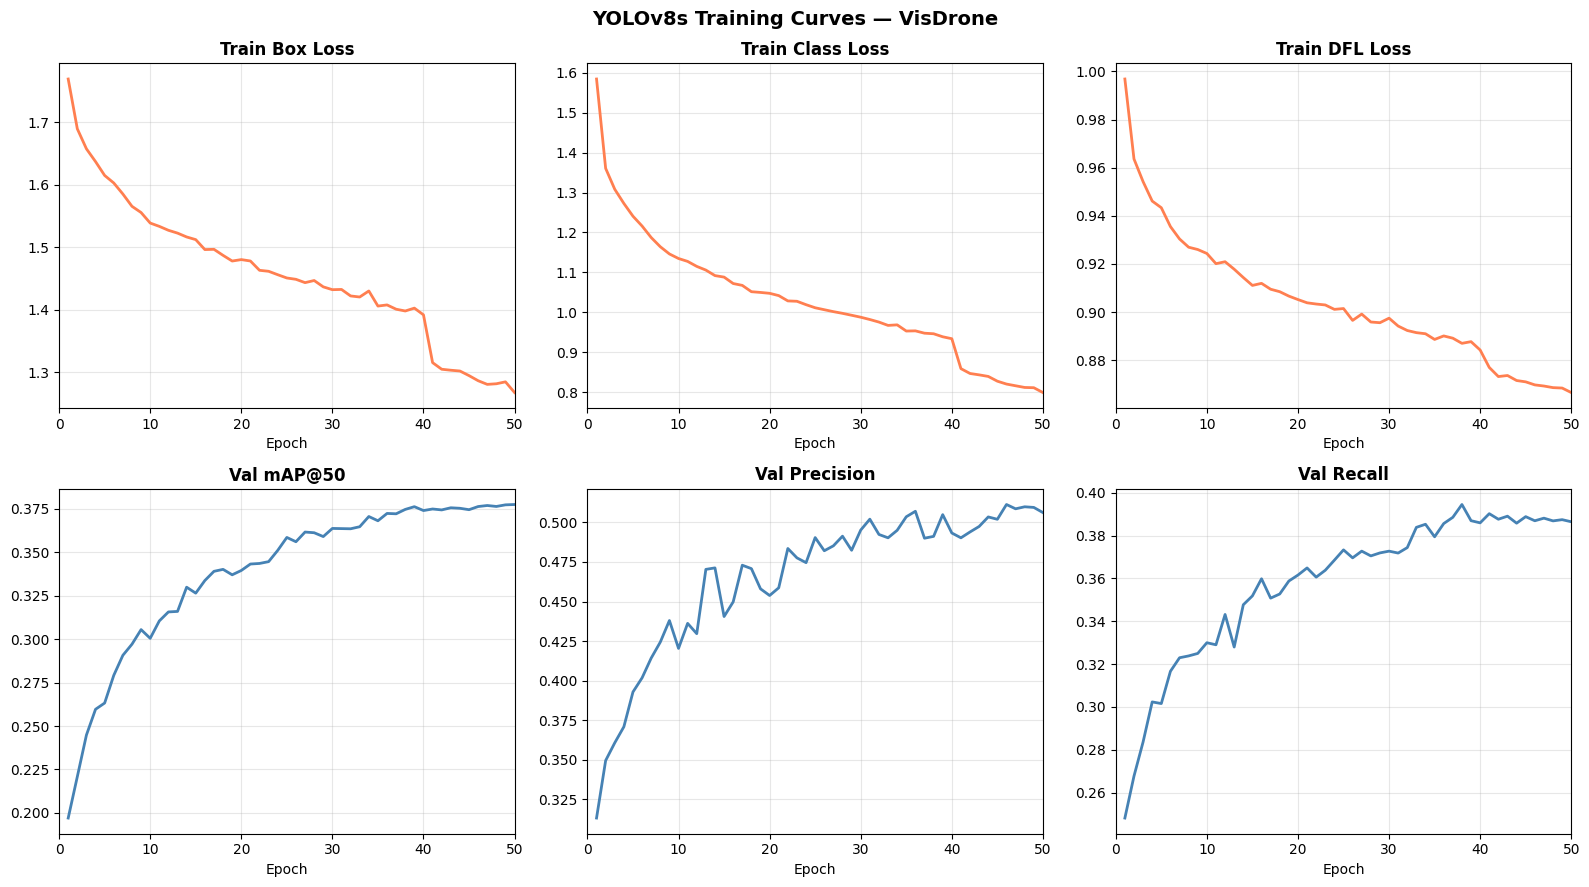

Saved → assets/sample_images/training_curves.png


In [4]:
import pandas as pd

results_csv = MODELS_DIR / "runs" / "visdrone_yolov8" / "results.csv"
df = pd.read_csv(results_csv)
df.columns = df.columns.str.strip()

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("YOLOv8s Training Curves — VisDrone", fontsize=14, fontweight="bold")

plots = [
    ("train/box_loss",  "Train Box Loss",       "coral"),
    ("train/cls_loss",  "Train Class Loss",     "coral"),
    ("train/dfl_loss",  "Train DFL Loss",       "coral"),
    ("metrics/mAP50(B)","Val mAP@50",           "steelblue"),
    ("metrics/precision(B)", "Val Precision",   "steelblue"),
    ("metrics/recall(B)",    "Val Recall",      "steelblue"),
]

for ax, (col, title, color) in zip(axes.flatten(), plots):
    if col in df.columns:
        ax.plot(df["epoch"], df[col], color=color, linewidth=2)
        ax.set_title(title, fontweight="bold")
        ax.set_xlabel("Epoch")
        ax.grid(True, alpha=0.3)
        ax.set_xlim(0, df["epoch"].max())

plt.tight_layout()
plt.savefig("../assets/sample_images/training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → assets/sample_images/training_curves.png")

In [5]:
val_results = model.val(
    data    = str(DATASET_YAML),
    imgsz   = IMG_SIZE,
    batch   = 8,
    conf    = CONF_THRESHOLD,
    iou     = IOU_THRESHOLD,
    device  = 0 if torch.cuda.is_available() else "cpu",
    verbose = True,
)

print("\n─── Key Metrics ───────────────────────────────")
print(f"mAP@50       : {val_results.box.map50:.4f}")
print(f"mAP@50-95    : {val_results.box.map:.4f}")
print(f"Precision    : {val_results.box.mp:.4f}")
print(f"Recall       : {val_results.box.mr:.4f}")

Ultralytics 8.4.50  Python-3.13.3 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
Model summary (fused): 73 layers, 11,129,454 parameters, 0 gradients, 28.5 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 247.399.6 MB/s, size: 111.3 KB)
val: Scanning D:\drone-detection\data\raw\VisDrone\VisDrone2019-DET-val\labels.cache... 548 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 548/548 95.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 69/69 8.1it/s 8.5s<0.2s
                   all        548      38759      0.586      0.354      0.296      0.186
            pedestrian        520       8844      0.651       0.38      0.332      0.155
                people        482       5125      0.688      0.254      0.213     0.0804
               bicycle        364       1287      0.319      0.148     0.0735     0.0356
                   car        515      14064      0.793      0.764      0.728 

In [12]:
print(f"\n{'Class':<20} {'Precision':>10} {'Recall':>8} {'mAP50':>8} {'mAP50-95':>10}")
print("─" * 60)

class_names_list = list(CLASS_NAMES.values())
for i, name in enumerate(class_names_list):
    try:
        p    = val_results.box.p[i]
        r    = val_results.box.r[i]
        ap50 = val_results.box.ap50[i]
        ap   = val_results.box.ap[i]
        marker = " ← human" if i in HUMAN_CLASS_IDS else (" ← car" if i in CAR_CLASS_IDS else "")
        print(f"{name:<20} {p:>10.3f} {r:>8.3f} {ap50:>8.3f} {ap:>10.3f}{marker}")
    except:
        pass

print("─" * 60)
print(f"{'ALL':<20} {val_results.box.mp:>10.3f} {val_results.box.mr:>8.3f} "
      f"{val_results.box.map50:>8.3f} {val_results.box.map:>10.3f}")

# Our task specific metrics
print("\n─── Our Task (Humans & Cars) ──────────────────")
human_ap50 = np.mean([val_results.box.ap50[i] for i in HUMAN_CLASS_IDS])
car_ap50   = np.mean([val_results.box.ap50[i] for i in CAR_CLASS_IDS])
print(f"Human detection mAP50 (avg) : {human_ap50:.4f}")
print(f"Car detection   mAP50 (avg) : {car_ap50:.4f}")


Class                 Precision   Recall    mAP50   mAP50-95
────────────────────────────────────────────────────────────
pedestrian                0.651    0.380    0.332      0.155 ← human
people                    0.688    0.254    0.213      0.080 ← human
bicycle                   0.319    0.148    0.074      0.036
car                       0.793    0.764    0.728      0.511 ← car
van                       0.573    0.403    0.328      0.245 ← car
truck                     0.596    0.355    0.285      0.206
tricycle                  0.534    0.238    0.167      0.102
awning-tricycle           0.357    0.150    0.087      0.061
bus                       0.718    0.466    0.435      0.320
motor                     0.634    0.381    0.315      0.140
────────────────────────────────────────────────────────────
ALL                       0.586    0.354    0.296      0.186

─── Our Task (Humans & Cars) ──────────────────
Human detection mAP50 (avg) : 0.2725
Car detection   mAP50 (avg) : 0

In [13]:
import time

val_img_dir = DATA_RAW_DIR / "VisDrone2019-DET-val" / IMAGES_FOLDER
test_images = list(val_img_dir.glob("*.jpg"))[:50]

# Warmup
_ = model.predict(str(test_images[0]), verbose=False)

# Benchmark
start = time.time()
for img_path in test_images:
    _ = model.predict(str(img_path), conf=CONF_THRESHOLD, verbose=False)
elapsed = time.time() - start

fps = len(test_images) / elapsed
print(f"Images tested   : {len(test_images)}")
print(f"Total time      : {elapsed:.2f}s")
print(f"FPS             : {fps:.1f}")
print(f"ms per image    : {1000/fps:.1f}ms")
print()
if fps >= 30:
    print("✅ Real-time capable (≥30 FPS)")
elif fps >= 15:
    print("⚡ Near real-time (15–30 FPS)")
else:
    print("🔄 Offline processing speed (<15 FPS)")

Images tested   : 50
Total time      : 1.28s
FPS             : 39.1
ms per image    : 25.6ms

✅ Real-time capable (≥30 FPS)


C:\Users\Mohammad Adnan Kabir\AppData\Local\Temp\ipykernel_21132\1485217136.py:46: UserWarning: Glyph 128100 (\N{BUST IN SILHOUETTE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Mohammad Adnan Kabir\AppData\Local\Temp\ipykernel_21132\1485217136.py:46: UserWarning: Glyph 128663 (\N{AUTOMOBILE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Mohammad Adnan Kabir\AppData\Local\Temp\ipykernel_21132\1485217136.py:47: UserWarning: Glyph 128100 (\N{BUST IN SILHOUETTE}) missing from font(s) DejaVu Sans.
  plt.savefig("../assets/sample_images/val_predictions.png",
C:\Users\Mohammad Adnan Kabir\AppData\Local\Temp\ipykernel_21132\1485217136.py:47: UserWarning: Glyph 128663 (\N{AUTOMOBILE}) missing from font(s) DejaVu Sans.
  plt.savefig("../assets/sample_images/val_predictions.png",


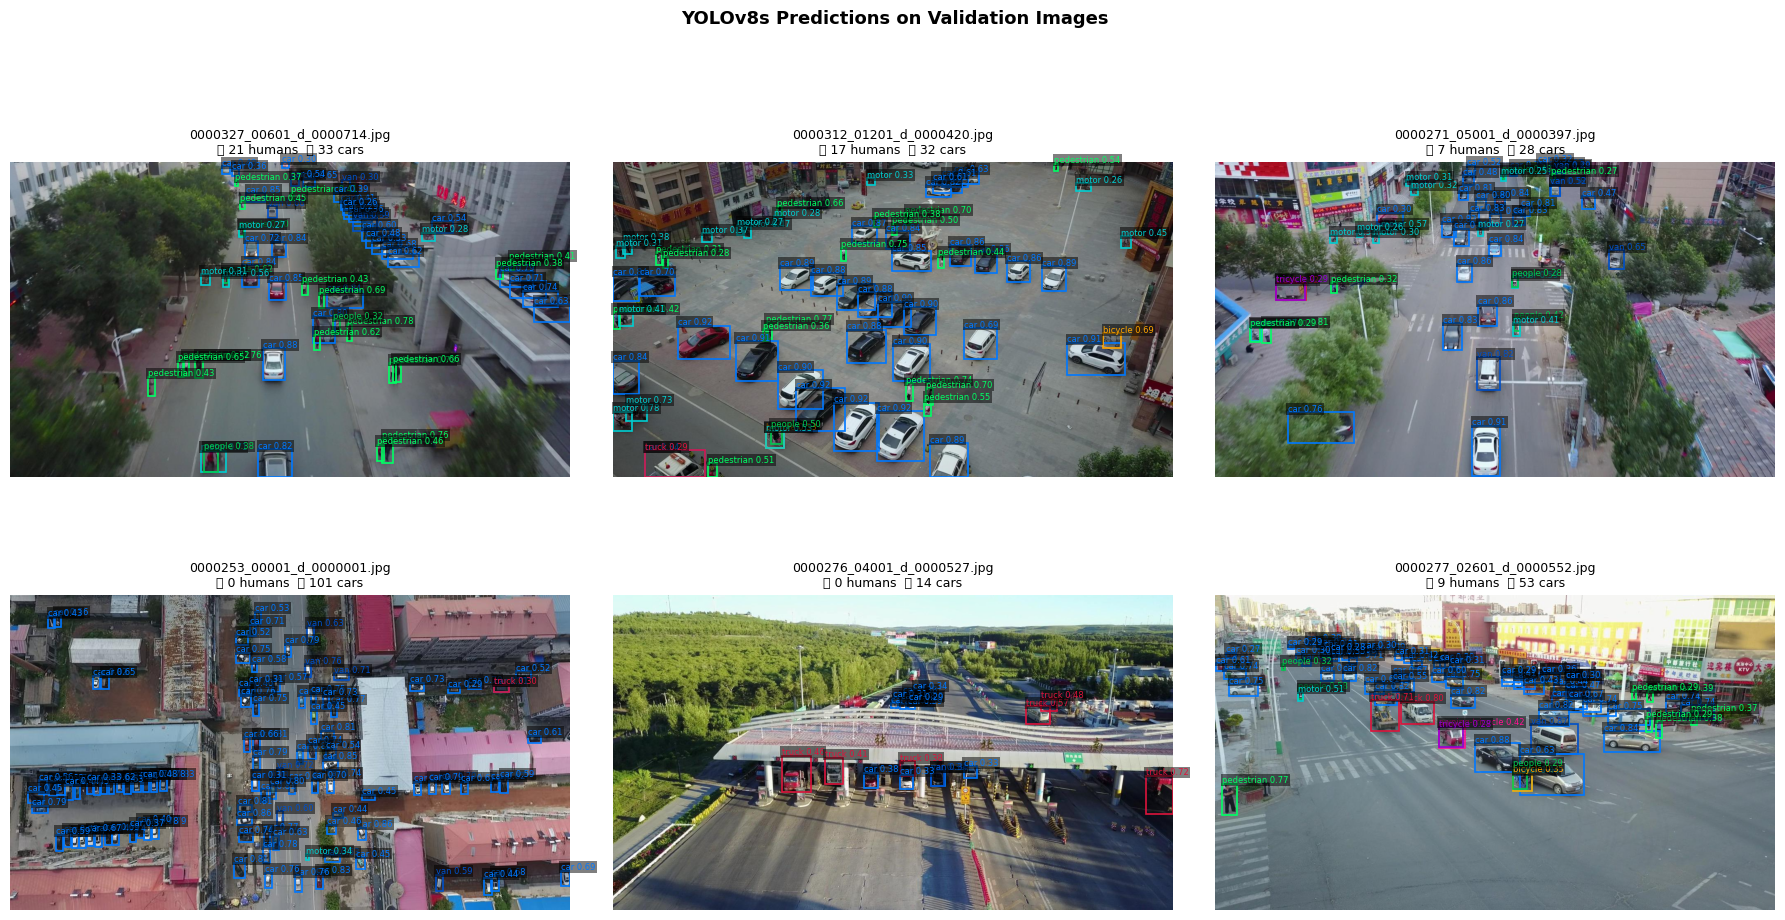

Saved → assets/sample_images/val_predictions.png


In [14]:
import random
random.seed(99)

val_img_dir = DATA_RAW_DIR / "VisDrone2019-DET-val" / IMAGES_FOLDER
sample_imgs = random.sample(list(val_img_dir.glob("*.jpg")), 6)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, img_path in zip(axes, sample_imgs):
    img_bgr = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    ih, iw  = img_rgb.shape[:2]

    results = model.predict(
        str(img_path),
        conf    = CONF_THRESHOLD,
        iou     = IOU_THRESHOLD,
        verbose = False,
    )[0]

    ax.imshow(img_rgb)

    humans, cars = 0, 0
    for box in results.boxes:
        cid   = int(box.cls)
        conf  = float(box.conf)
        x1,y1,x2,y2 = box.xyxy[0].tolist()
        color = [c/255 for c in CLASS_COLORS.get(cid, (255,255,255))]
        rect  = patches.Rectangle(
                    (x1,y1), x2-x1, y2-y1,
                    linewidth=1.2, edgecolor=color, facecolor="none")
        ax.add_patch(rect)
        ax.text(x1, y1-2, f"{CLASS_NAMES[cid]} {conf:.2f}",
                fontsize=6, color=color,
                bbox=dict(facecolor="black", alpha=0.5, pad=1, edgecolor="none"))
        if cid in HUMAN_CLASS_IDS: humans += 1
        if cid in CAR_CLASS_IDS:   cars   += 1

    ax.set_title(f"{img_path.name}\n👤 {humans} humans  🚗 {cars} cars",
                 fontsize=9)
    ax.axis("off")

plt.suptitle("YOLOv8s Predictions on Validation Images",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("../assets/sample_images/val_predictions.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved → assets/sample_images/val_predictions.png")

In [15]:
import shutil

run_dir    = MODELS_DIR / "runs" / "visdrone_yolov8"
asset_dir  = ROOT_DIR / "assets" / "sample_images"
asset_dir.mkdir(parents=True, exist_ok=True)

files_to_copy = [
    "confusion_matrix.png",
    "confusion_matrix_normalized.png",
    "PR_curve.png",
    "P_curve.png",
    "R_curve.png",
    "F1_curve.png",
    "results.png",
]

for fname in files_to_copy:
    src = run_dir / fname
    if src.exists():
        shutil.copy(src, asset_dir / fname)
        print(f"✅ Copied {fname}")
    else:
        print(f"⚠️  Not found: {fname}")

print(f"\nAll evaluation assets saved to {asset_dir}")

✅ Copied confusion_matrix.png
✅ Copied confusion_matrix_normalized.png
⚠️  Not found: PR_curve.png
⚠️  Not found: P_curve.png
⚠️  Not found: R_curve.png
⚠️  Not found: F1_curve.png
✅ Copied results.png

All evaluation assets saved to D:\drone-detection\assets\sample_images


In [16]:
run_dir = MODELS_DIR / "runs" / "visdrone_yolov8"
print("Files in run directory:")
for f in sorted(run_dir.rglob("*.png")):
    print(f"  {f.relative_to(run_dir)}")

Files in run directory:
  BoxF1_curve.png
  BoxP_curve.png
  BoxPR_curve.png
  BoxR_curve.png
  confusion_matrix.png
  confusion_matrix_normalized.png
  results.png


In [17]:
import shutil

run_dir   = MODELS_DIR / "runs" / "visdrone_yolov8"
asset_dir = ROOT_DIR / "assets" / "sample_images"

files_to_copy = [
    "BoxF1_curve.png",
    "BoxP_curve.png",
    "BoxPR_curve.png",
    "BoxR_curve.png",
    "confusion_matrix.png",
    "confusion_matrix_normalized.png",
    "results.png",
]

for fname in files_to_copy:
    src = run_dir / fname
    if src.exists():
        shutil.copy(src, asset_dir / fname)
        print(f"✅ Copied {fname}")
    else:
        print(f"⚠️  Not found: {fname}")

print(f"\nAll assets saved → {asset_dir}")

✅ Copied BoxF1_curve.png
✅ Copied BoxP_curve.png
✅ Copied BoxPR_curve.png
✅ Copied BoxR_curve.png
✅ Copied confusion_matrix.png
✅ Copied confusion_matrix_normalized.png
✅ Copied results.png

All assets saved → D:\drone-detection\assets\sample_images
